# Задание Pro

Используя датасет "Пассажиры автобуса", создайте нейронную сеть для решения задачи классификации пассажиров на входящих и выходящих.

Добейтесь точности работы модели выше 90% на проверочной выборке

In [1]:

from PIL import Image
import matplotlib.pyplot as plt
import random
import numpy as np
import os
import shutil
import gdown
import time

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization
from tensorflow.keras.preprocessing import image
from tensorflow.keras.optimizers import Adam


In [2]:
# загрузка датасета
DATA_URL = 'https://storage.yandexcloud.net/aiueducation/Content/base/l4/bus.zip'
ZIP_PATH = '/content/bus.zip'
IMAGE_PATH = '/content/bus/'

if not os.path.exists(ZIP_PATH):
    gdown.download(DATA_URL, ZIP_PATH, quiet=True)

# Очищаем старую папку
if os.path.exists(IMAGE_PATH):
    shutil.rmtree(IMAGE_PATH)

os.makedirs(IMAGE_PATH, exist_ok=True)

# Распакуем архив в директорию
!unzip -q -o "{ZIP_PATH}" -d "{IMAGE_PATH}"

os.listdir(IMAGE_PATH)


['Входящий', 'Выходящий']

In [3]:
# Определение списка имен классов
CLASS_LIST = sorted([
    name for name in os.listdir(IMAGE_PATH)
    if os.path.isdir(os.path.join(IMAGE_PATH, name)) and not name.startswith('.')
])

# Определение количества классов
CLASS_COUNT = len(CLASS_LIST)

# Проверка результата
print(f'Количество классов: {CLASS_COUNT}, метки классов: {CLASS_LIST}')

# Получение списка файлов для каждого класса
for cls in CLASS_LIST:
    class_path = os.path.join(IMAGE_PATH, cls)
    print(cls, ':', os.listdir(class_path)[:10])


Количество классов: 2, метки классов: ['Входящий', 'Выходящий']
Входящий : ['02144.jpg', '06131.jpg', '02820.jpg', '00862.jpg', '04659.jpg', '06246.jpg', '06392.jpg', '05128.jpg', '06366.jpg', '03551.jpg']
Выходящий : ['02144.jpg', '00862.jpg', '00723.jpg', '00567.jpg', '01940.jpg', '01023.jpg', '01071.jpg', '01306.jpg', '00545.jpg', '02135.jpg']


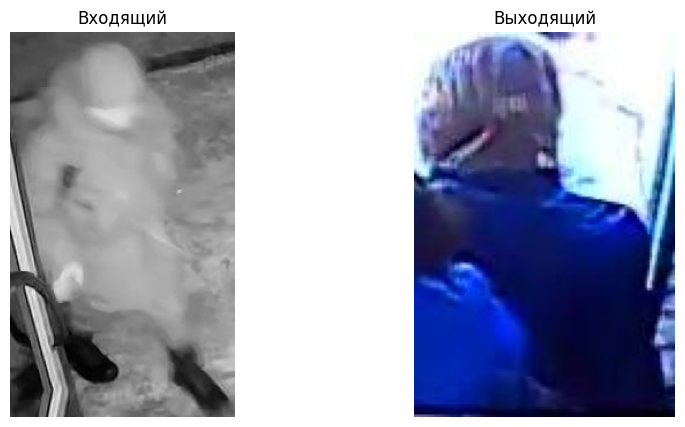

In [4]:
# Создание заготовки для изображений всех классов
fig, axs = plt.subplots(1, CLASS_COUNT, figsize=(10, 5))
axs = np.atleast_1d(axs)

# Для всех номеров классов
for i in range(CLASS_COUNT):

    # Формирование пути к папке содержимого класса
    class_path = os.path.join(IMAGE_PATH, CLASS_LIST[i])

    # Берём только файлы изображений
    image_names = [
        file_name for file_name in os.listdir(class_path)
        if file_name.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
    ]

    img_path = os.path.join(class_path, random.choice(image_names))

    # Отображение фотографии
    axs[i].set_title(CLASS_LIST[i])
    axs[i].imshow(Image.open(img_path))
    axs[i].axis('off')


plt.show()


In [5]:
data_files = []                           # Cписок путей к файлам картинок
data_labels = []                          # Список меток классов
valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp')

for class_label, class_name in enumerate(CLASS_LIST):
    class_path = os.path.join(IMAGE_PATH, class_name)

    # Получение списка файлов с изображениями текущего класса
    class_files = [
        file_name for file_name in os.listdir(class_path)
        if file_name.lower().endswith(valid_extensions)
    ]

    print(f'Размер класса {class_name} составляет {len(class_files)} фото')

    # Добавление к общему списку всех файлов класса с добавлением родительского пути
    data_files += [os.path.join(class_path, file_name) for file_name in class_files]

    # Добавление к общему списку меток текущего класса
    data_labels += [class_label] * len(class_files)

print()
print('Общий размер базы для обучения:', len(data_labels))


Размер класса Входящий составляет 6485 фото
Размер класса Выходящий составляет 2596 фото

Общий размер базы для обучения: 9081


In [6]:
class Passenger:
    def __init__(self, epochs=64, batch_size=8):
        self.epochs = epochs
        self.batch_size = batch_size
        self.img_height = 120
        self.img_width = 80
        self.model = None
        self.history = None

    # загрузка датасета
    def load_dataset(self):
        x_data = []
        y_data = []

        for file_path, label in zip(data_files, data_labels):
            try:
                img = image.load_img(
                    file_path,
                    target_size=(self.img_height, self.img_width),
                    color_mode='grayscale'
                )

                img_array = image.img_to_array(img)
                x_data.append(img_array)
                y_data.append(label)

            except Exception as error:
                print(f'Файл пропущен: {file_path}. Причина: {error}')

        if len(x_data) == 0:
            raise ValueError('Изображения не загружены. Проверьте путь к датасету и структуру папок.')

        x_data = np.array(x_data, dtype='float32') / 255.0
        y_data = np.array(y_data, dtype='float32')

        return x_data, y_data

    def load_data(self):
        x_data, y_data = self.load_dataset()

        np.random.seed(42)
        tf.keras.utils.set_random_seed(42)

        # тестовая выборка
        x_train_val, x_test, y_train_val, y_test = train_test_split(
            x_data,
            y_data,
            test_size=0.2,
            random_state=42,
            stratify=y_data
        )

        # проверочная выборка
        x_train, x_val, y_train, y_val = train_test_split(
            x_train_val,
            y_train_val,
            test_size=0.25,
            random_state=42,
            stratify=y_train_val
        )

        return x_train, y_train, x_val, y_val, x_test, y_test

    # создание модели
    def create_model(self):
        model = Sequential(name='passenger_classifier')

        model.add(Input(shape=(self.img_height, self.img_width, 1)))

        model.add(Conv2D(32, (3, 3), padding='same', activation='relu'))
        model.add(BatchNormalization())
        model.add(MaxPooling2D(pool_size=(2, 2)))
        model.add(Dropout(0.2))

        model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
        model.add(BatchNormalization())
        model.add(MaxPooling2D(pool_size=(2, 2)))
        model.add(Dropout(0.3))

        model.add(Flatten())

        model.add(Dense(128, activation='relu'))
        model.add(Dropout(0.4))

        model.add(Dense(1, activation='sigmoid'))

        model.compile(
            loss='binary_crossentropy',
            optimizer=Adam(learning_rate=0.001),
            metrics=['accuracy']
        )

        return model

    # обучение модели
    def train_model(self):
        x_train, y_train, x_val, y_val, x_test, y_test = self.load_data()

        model = self.create_model()

        # обучение
        history = model.fit(
            x_train,
            y_train,
            epochs=self.epochs,
            batch_size=self.batch_size,
            verbose=1,
            shuffle=True,
            validation_data=(x_val, y_val)
        )

        # проверка качества на тестовой выборке
        test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

        self.model = model
        self.history = history

        print(f'Точность на тестовой выборке: {test_accuracy * 100:.2f}%')
        print(f'Ошибка на тестовой выборке: {test_loss:.4f}')

        return model, history, test_loss, test_accuracy

    # графики
    def show_graphs(self, history=None):
        if history is None:
            history = self.history

        if history is None:
            raise ValueError('История обучения отсутствует. Сначала выполните train_model().')

        epochs = range(1, len(history.history['accuracy']) + 1)

        plt.figure(figsize=(10, 5))

        plt.plot(epochs, history.history['accuracy'], label='Точность на обучающей выборке')
        plt.plot(epochs, history.history['val_accuracy'], label='Точность на проверочной выборке')

        plt.xlabel('Эпоха')
        plt.ylabel('Точность')
        plt.title('График точности модели')
        plt.legend()
        plt.grid()
        plt.show()

        plt.figure(figsize=(10, 5))

        plt.plot(epochs, history.history['loss'], label='Ошибка на обучающей выборке')
        plt.plot(epochs, history.history['val_loss'], label='Ошибка на проверочной выборке')

        plt.xlabel('Эпоха')
        plt.ylabel('Ошибка')
        plt.title('График ошибки модели')
        plt.legend()
        plt.grid()
        plt.show()


In [7]:
passenger = Passenger(epochs=18, batch_size=8)
model, history, loss, accuracy = passenger.train_model()
model.summary()


Epoch 1/18
681/681 ━━━━━━━━━━━━━━━━━━━━ 157s 227ms/step - accuracy: 0.7410 - loss: 1.0842 - val_accuracy: 0.7643 - val_loss: 0.5624
Epoch 2/18
681/681 ━━━━━━━━━━━━━━━━━━━━ 153s 224ms/step - accuracy: 0.8056 - loss: 0.4309 - val_accuracy: 0.8287 - val_loss: 0.3668
Epoch 3/18
681/681 ━━━━━━━━━━━━━━━━━━━━ 199s 219ms/step - accuracy: 0.8486 - loss: 0.3326 - val_accuracy: 0.8596 - val_loss: 0.3647
Epoch 4/18
681/681 ━━━━━━━━━━━━━━━━━━━━ 149s 219ms/step - accuracy: 0.8783 - loss: 0.2844 - val_accuracy: 0.9091 - val_loss: 0.2347
Epoch 5/18
681/681 ━━━━━━━━━━━━━━━━━━━━ 151s 222ms/step - accuracy: 0.9051 - loss: 0.2244 - val_accuracy: 0.9229 - val_loss: 0.1946
Epoch 6/18
681/681 ━━━━━━━━━━━━━━━━━━━━ 152s 223ms/step - accuracy: 0.9218 - loss: 0.1979 - val_accuracy: 0.9295 - val_loss: 0.1987
Epoch 7/18
681/681 ━━━━━━━━━━━━━━━━━━━━ 204s 226ms/step - accuracy: 0.9258 - loss: 0.1743 - val_accuracy: 0.9091 - val_loss: 0.2384
Epoch 8/18
681/681 ━━━━━━━━━━━━━━━━━━━━ 149s 219ms/step - accuracy: 0.9389 -

Model: "passenger_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 120, 80, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 120, 80, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 60, 40, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 40, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 60, 40, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 60, 40, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 38400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,915,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,803,589 (56.47 MB)

 Trainable params: 4,934,465 (18.82 MB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 9,868,932 (37.65 MB)

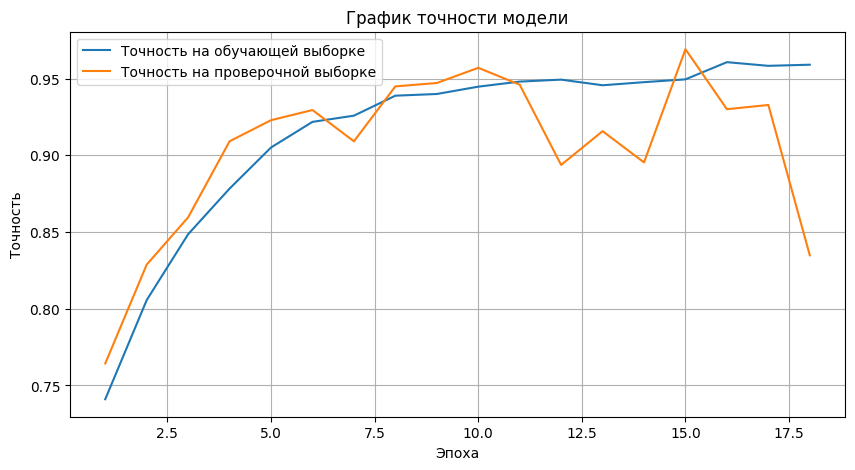

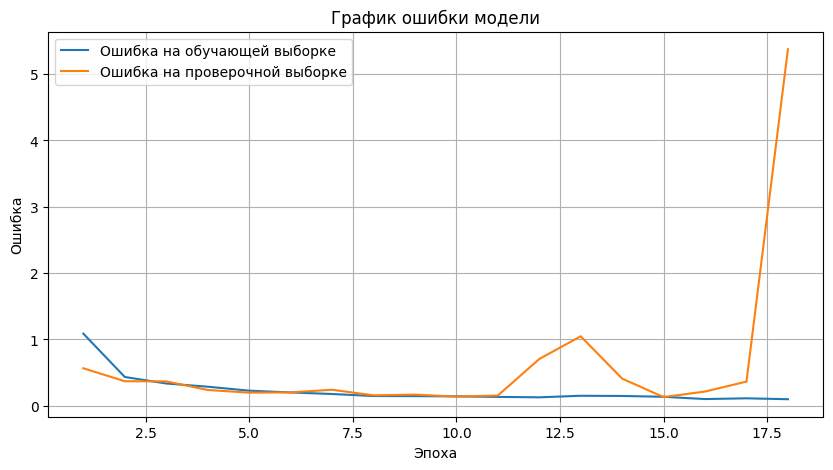

In [8]:
passenger.show_graphs(history)
